In [1]:
!pip install yfinance --upgrade

INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 1.6/1.6 MB 6.2 MB/s  0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2022.1
    Uninstalling pytz-2022.1:
      Successfully uninstalled pytz-2022.1
  Attempting uninstall: certifi
    Found existing installation: certifi 2022.9.14
    Uninstalling certifi-2022.9.14:
      Successfully uninstalled certifi-2022.9.14
  Attempting uninstall: requests
    Found existing installation: requests 2.28.1
    Uninstalling requests-2.28.1:
      Successfully uninstalled requests-2.28.1



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-project 0.11.1 requires ruamel-yaml, which is not installed.
spyder 5.2.2 requires pyqt5<5.13, which is not installed.
spyder 5.2.2 requires pyqtwebengine<5.13, which is not installed.
conda-repo-cli 1.0.20 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.20 requires nbformat==5.4.0, but you have nbformat 5.5.0 which is incompatible.
conda-repo-cli 1.0.20 requires requests==2.28.1, but you have requests 2.32.5 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance 
import pandas as pd
data = yfinance.download("AAPL",start="2015-01-01",end="2023-01-01")
print(data)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2015-01-02   24.192604   24.659506   23.754468   24.648441  212818400
2015-01-05   23.511061   24.042134   23.325186   23.962473  257142000
2015-01-06   23.513271   23.772169   23.152583   23.575230  263188400
2015-01-07   23.842981   23.942557   23.610636   23.721276  160423600
2015-01-08   24.759081   24.816614   24.053195   24.170475  237458000
...                ...         ...         ...         ...        ...
2022-12-23  129.659409  130.210060  127.476457  128.735094   63814900
2022-12-27  127.859932  129.216906  126.571797  129.187408   69007800
2022-12-28  123.936523  128.843243  123.769362  127.505940   85438400
2022-12-29  127.446938  128.302413  125.598316  125.853971   75703700
2022-12-30  127.761597  127.781267  125.303327  126.266975   77034200

[2014 rows x 5 colu

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

minmax = MinMaxScaler()
scaleddata = minmax.fit_transform(data["Close"])
print(scaleddata)

[[0.02304533]
 [0.0187146 ]
 [0.01872865]
 ...
 [0.65684774]
 [0.67915395]
 [0.68115339]]


In [7]:
seqLen = 60
X = []
y = []
for pos in range(len(scaleddata)-seqLen): 
    X.append(scaleddata[pos:pos+seqLen])
    y.append(scaleddata[pos+seqLen])

X = np.array(X)
y = np.array(y)
print(X[0])
print(y[0])

[[0.02304533]
 [0.0187146 ]
 [0.01872865]
 [0.02082372]
 [0.02664489]
 [0.02681362]
 [0.02293286]
 [0.02429676]
 [0.02370619]
 [0.01951606]
 [0.01834902]
 [0.02218765]
 [0.02335465]
 [0.02736201]
 [0.02817753]
 [0.02834626]
 [0.02277816]
 [0.03145375]
 [0.03650153]
 [0.034055  ]
 [0.03612188]
 [0.03614999]
 [0.0374296 ]
 [0.03862943]
 [0.03720372]
 [0.03831887]
 [0.04156564]
 [0.04560286]
 [0.04783325]
 [0.04870849]
 [0.04976718]
 [0.05102354]
 [0.05064244]
 [0.05212464]
 [0.05706539]
 [0.05589366]
 [0.05112239]
 [0.05342332]
 [0.05065655]
 [0.05154583]
 [0.05192701]
 [0.05076946]
 [0.0477627 ]
 [0.04803091]
 [0.04879319]
 [0.04508062]
 [0.04187619]
 [0.04499588]
 [0.04378192]
 [0.04570172]
 [0.04865204]
 [0.05067064]
 [0.04930139]
 [0.04704276]
 [0.04889199]
 [0.04815795]
 [0.04348543]
 [0.04469942]
 [0.0433019 ]
 [0.0477062 ]]
[0.04496768]


In [9]:
print(X.shape)

(1954, 60, 1)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

model = Sequential()
model.add(LSTM(units=50,return_sequences=True,input_shape=X.shape[1:]))
model.add(Dropout(0.2))
model.add(LSTM(units=50,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer="adam",loss="mean_squared_error")

In [11]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=1)

In [12]:
model.fit(Xtrain,ytrain,epochs=50,batch_size=32,validation_data=(Xtest,ytest))

Epoch 1/50
49/49 [==============================] - 3s 30ms/step - loss: 0.0271 - val_loss: 9.0106e-04
Epoch 2/50
49/49 [==============================] - 1s 21ms/step - loss: 0.0028 - val_loss: 7.1701e-04
Epoch 3/50
49/49 [==============================] - 1s 21ms/step - loss: 0.0026 - val_loss: 6.7233e-04
Epoch 4/50
49/49 [==============================] - 1s 21ms/step - loss: 0.0025 - val_loss: 0.0017
Epoch 5/50
49/49 [==============================] - 1s 22ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 6/50
49/49 [==============================] - 1s 21ms/step - loss: 0.0023 - val_loss: 5.3887e-04
Epoch 7/50
49/49 [==============================] - 1s 21ms/step - loss: 0.0020 - val_loss: 5.7977e-04
Epoch 8/50
49/49 [==============================] - 1s 21ms/step - loss: 0.0019 - val_loss: 5.0166e-04
Epoch 9/50
49/49 [==============================] - 1s 22ms/step - loss: 0.0018 - val_loss: 5.0045e-04
Epoch 10/50
49/49 [==============================] - 1s 22ms/step - loss: 0.0020 

In [25]:
pred = model.predict(Xtest)
newPred = minmax.inverse_transform(pred).reshape(-1,1)
newytest = minmax.inverse_transform(ytest).reshape(-1,1)
print(newPred[0:10])
print(newytest[0:10])

13/13 [==============================] - 0s 8ms/step
[[143.81834 ]
 [130.94244 ]
 [144.76825 ]
 [109.08947 ]
 [124.262085]
 [ 53.527668]
 [140.05731 ]
 [ 25.73037 ]
 [ 26.432804]
 [ 53.663105]]
[[139.83299255]
 [136.42630005]
 [145.53985596]
 [103.63198853]
 [128.22825623]
 [ 50.70497894]
 [144.7311554 ]
 [ 25.40070915]
 [ 26.14415169]
 [ 53.03157806]]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(newytest,newPred)
mse = mean_squared_error(newytest,newPred)
print(mae)
print(mse)

1.8427860230740989
8.783412469388162


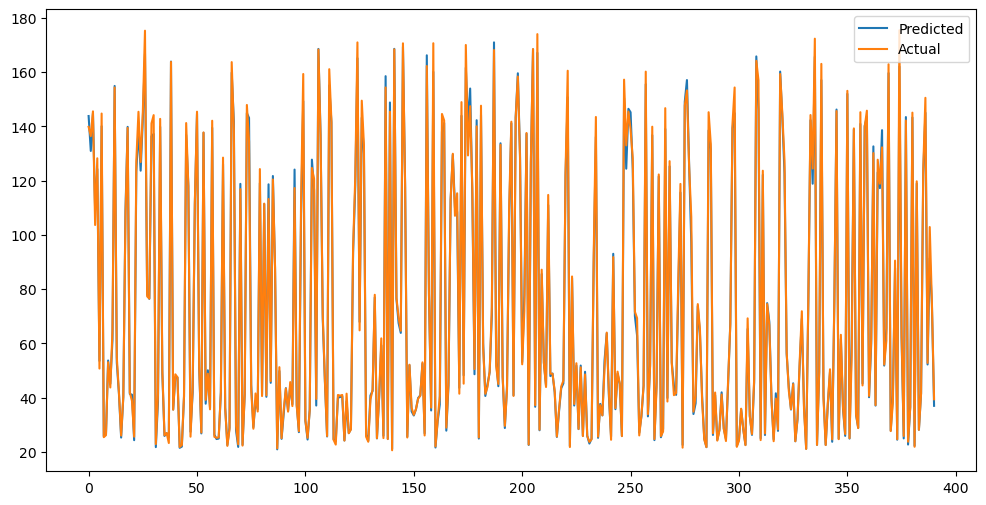

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(newPred,label="Predicted")
plt.plot(newytest,label="Actual")

plt.legend()
plt.show()